# Movies Dataset

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import re
import string

## 1. Data Loading

### Loading

In [3]:
from rital.movies.data import load_movies, load_movies_unseen

In [4]:
x, y = load_movies()

In [5]:
x_unseen = load_movies_unseen()

In [7]:
print(f"Size of Dataset: {len(y)}")
print(f"Number of negative samples: {len(y) - np.sum(y)}")
print(f"Number of positive samples: {np.sum(y)}")

Size of Dataset: 2000
Number of negative samples: 1000
Number of positive samples: 1000


We don't do any additional preprocessing here as we may choose the preprocessing as a hyperparameter later in our models.

### Matching the unseen data to the current data

The data from the unlabelled dataset is differently formatted from that of the labelled. To do this we will try to preprocess the labelled dataset to match more like that of the unseen data.

In [6]:
print(x[0])
print(x_unseen[0])

assume nothing . the phrase is perhaps one of the most used of the 1990's , as first impressions and rumors are hardly ever what they seem to be . the phrase especially goes for oscar novak , an architect who is the main focus of three to tango , a delightful , funny romantic comedy about assumptions and being yourself . novak ( matthew perry ) , a shy , clumsy , chicago based architect , along with openly gay partner , peter steinberg ( oliver platt ) , fights for projects day in and day out . one of these is the job of restoring a popular building for charles newman ( dylan mcdermott ) , a rich , well-known businessman . charles immediately takes a liking to oscar , as he enjoys his personality and sense of humor . seeing oscar as someone he could trust , charles asks him to watch his girlfriend , an unpredictable , adventurous girl named amy post ( neve campbell ) , who makes a living by blowing glass . charles wants to know who she talks to , what she does , and where she goes . th

In [7]:
from rital.movies.preprocessing import normalize


In [10]:
normalize("Happy birthday")

'happy birthday'

In [9]:
x = [normalize(x_i) for x_i in x]
x_unseen = [normalize(x_i) for x_i in x_unseen]

In [10]:
print(x[0])
print(x_unseen[0])

assume nothing. the phrase is perhaps one of the most used of the 1990's, as first impressions and rumors are hardly ever what they seem to be. the phrase especially goes for oscar novak, an architect who is the main focus of three to tango, a delightful, funny romantic comedy about assumptions and being yourself. novak (matthew perry), a shy, clumsy, chicago based architect, along with openly gay partner, peter steinberg (oliver platt), fights for projects day in and day out. one of these is the job of restoring a popular building for charles newman (dylan mcdermott), a rich, well-known businessman. charles immediately takes a liking to oscar, as he enjoys his personality and sense of humor. seeing oscar as someone he could trust, charles asks him to watch his girlfriend, an unpredictable, adventurous girl named amy post (neve campbell), who makes a living by blowing glass. charles wants to know who she talks to, what she does, and where she goes. the point? to make sure she's not see

---

Steal the real data for evaluation

In [11]:
from datasets import load_dataset

ds = load_dataset("stanfordnlp/imdb")

x_eval = [normalize(ds["train"][i]["text"]) for i in range(ds["train"].num_rows)]
y_eval = [ds["train"][i]["label"] for i in range(ds["train"].num_rows)]

## 2. Exploratory Data Analysis

In [39]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from rital.preprocessing import plot_word_cloud, preprocess
from nltk.corpus import stopwords

vectorizer = CountVectorizer(ngram_range=(1, 2), stop_words=stopwords.words())
X = vectorizer.fit_transform(x)
vocab = vectorizer.get_feature_names_out()

/Users/milosoundjian/Documents/sorbonne/nlp-document-classification/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['acaba', 'aldiz', 'baiknya', 'baizik', 'berkali', 'bukatzeko', 'edota', 'eze', 'ezpabere', 'ezpada', 'ezperen', 'gainera', 'gainerontzean', 'guztiz', 'hainbestez', 'horra', 'kali', 'kurangnya', 'mata', 'olah', 'onların', 'ordea', 'osterantzean', 'printr', 'sekurang', 'setidak', 'tama', 'tidaknya', 'δι', 'арбаң', 'арсалаң', 'афташ', 'бай', 'бале', 'баски', 'батыр', 'баҳри', 'болои', 'бүгжең', 'бұтыр', 'валекин', 'вақте', 'вой', 'вуҷуди', 'гар', 'гарчанде', 'далаң', 'даме', 'ербелең', 'жалт', 'жұлт', 'карда', 'кошки', 'куя', 'күңгір', 'кӣ', 'магар', 'майлаш', 'митың', 'модоме', 'нияти', 'онан', 'оре', 'паһ', 'рӯи', 'рӯஅங', 'салаң', 'сар', 'сұлаң', 'сұрт', 'тарбаң', 'тразе', 'ту', 'тыржың', 'тұрс', 'хом', 'хуб', 'чаро', 'чи', 'чун',

In [40]:
X.sum(0)
wc = WordCloud()

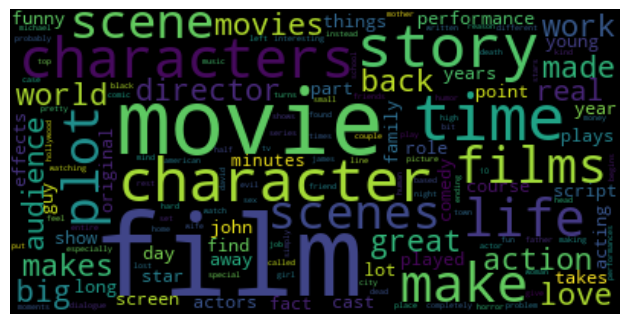

In [41]:
plot_word_cloud(vocab, X.sum(0).A1)

---

## 3. Models

In [120]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    train_test_split,
    cross_validate,
    cross_val_predict,
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Model 1: TF-IDF and Linear SVC

#### Model

The first model we use is just a simple `TfIdfVectorizer` into `LinearSVC`with default parameters.

In [121]:
from rital.preprocessing import preprocess

In [122]:
model_svc = Pipeline([("tfidf", TfidfVectorizer()), ("clf", LinearSVC())])

skf = StratifiedKFold(shuffle=True, random_state=0)

scores = cross_validate(
    model_svc,
    x,
    y,
    cv=skf,
    scoring=["accuracy", "f1", "precision", "recall"],
)

print("Accuracy:", np.mean(scores["test_accuracy"]))
print("F1:", np.mean(scores["test_f1"]))
print("Precision:", np.mean(scores["test_precision"]))
print("Recall:", np.mean(scores["test_recall"]))

Accuracy: 0.8465
F1: 0.8472700855105251
Precision: 0.8428019230058335
Recall: 0.852


We find that the result we get is usually around 85% accuracy and also around 0.85 for F1, Precision and Recall.

Let's also look at the confusion matrix

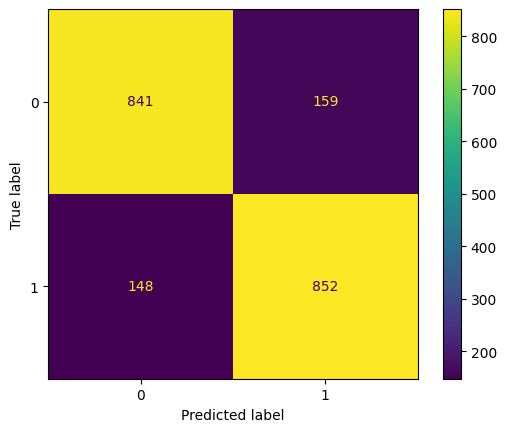

In [123]:
y_pred = cross_val_predict(model_svc, x, y, cv=skf)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [124]:
from sklearn.metrics import classification_report

Illegal line

In [136]:
# Evaluate the model on the real data
model_svc = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=5,
                max_df=0.9,
                smooth_idf=True,
            ),
        ),
        ("clf", LogisticRegression(C=10)),
    ]
)
model_svc.fit(x, y)
y_pred = model_svc.predict(x)
y_eval_pred = model_svc.predict(x_eval)
print(classification_report(y, y_pred))
print()
print(classification_report(y_eval, y_eval_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


              precision    recall  f1-score   support

           0       0.80      0.89      0.84     12500
           1       0.88      0.77      0.82     12500

    accuracy                           0.83     25000
   macro avg       0.84      0.83      0.83     25000
weighted avg       0.84      0.83      0.83     25000



From the confusion matrix we see that the model seems to perform similarly well on negative and positive reviews.

#### Tuning Hyperparameters

Right now we are using the TF-IDF with default parameters we can probably improve the performance by tuning the hyperparameters of the model.

In [9]:
param_grid_svc = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 3, 5],
    "tfidf__max_df": [0.7, 0.8, 1.0],
    # "tfidf__stop_words": [None, "english"],
    "tfidf__sublinear_tf": [False, True],
    "clf__C": [1, 10, 20],
}

grid_svc = GridSearchCV(
    model_svc, param_grid=param_grid_svc, cv=skf, n_jobs=-1
)  # The default scoring is "accuracy"

grid_svc.fit(x, y)

print(f"Best score: {grid_svc.best_score_}")
print(f"Best params: {grid_svc.best_params_}")

best_model_svc = grid_svc.best_estimator_

Best score: 0.89
Best params: {'clf__C': 10, 'tfidf__max_df': 0.7, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}


In [127]:
scores = cross_validate(
    best_model_svc,
    x,
    y,
    cv=skf,
    scoring=["accuracy", "f1", "precision", "recall"],
)

print("Accuracy:", np.mean(scores["test_accuracy"]))
print("F1:", np.mean(scores["test_f1"]))
print("Precision:", np.mean(scores["test_precision"]))
print("Recall:", np.mean(scores["test_recall"]))

NameError: name 'best_model_svc' is not defined

We have improved our performance for scores from ~0.85 to ~0.89 which is not bad.

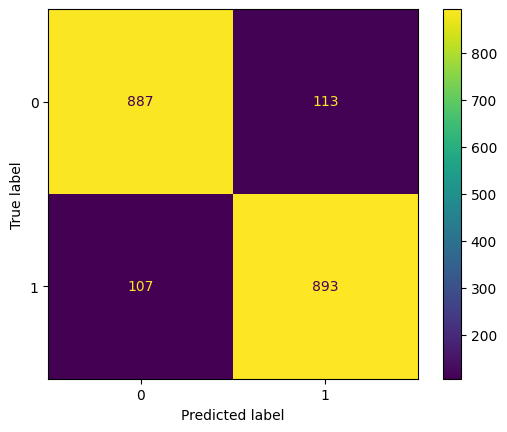

In [11]:
y_pred = cross_val_predict(best_model_svc, x, y, cv=skf)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

Train the model on the full dataset before using it on the unseen data.

In [ ]:
best_model_svc.fit(x, y)
y_unseen_pred = best_model_svc.predict(x_unseen)

In [ ]:
# write_prediction_movies(y_unseen_pred, "tfidf-svc-movies.csv")

The confusion matrix shows that our performance improved for both categories.

### Model 2: Logistic Regression

#### Model

In [12]:
model_lr = Pipeline([("tfidf", TfidfVectorizer()), ("clf", LogisticRegression())])

scores = cross_validate(
    model_lr,
    x,
    y,
    cv=skf,
    scoring=["accuracy", "f1", "precision", "recall"],
)

print("Accuracy:", np.mean(scores["test_accuracy"]))
print("F1:", np.mean(scores["test_f1"]))
print("Precision:", np.mean(scores["test_precision"]))
print("Recall:", np.mean(scores["test_recall"]))

Accuracy: 0.8244999999999999
F1: 0.8245600338152496
Precision: 0.8231952444815421
Recall: 0.827


The base performance is a bit worse at ~0.82.

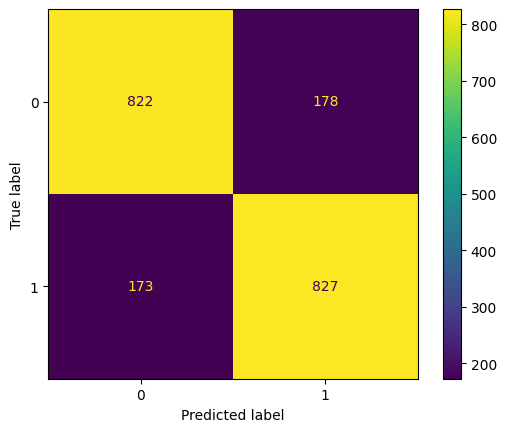

In [13]:
y_pred = cross_val_predict(model_lr, x, y, cv=skf)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

#### Tuning Hyperparameters

In [14]:
param_grid_lr = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [3, 5, 7],
    "tfidf__max_df": [0.8, 0.9, 1.0],
    "tfidf__stop_words": [None, "english"],
    "tfidf__sublinear_tf": [False, True],
    "clf__C": [10, 20, 40],
}

grid_lr = GridSearchCV(
    model_lr, param_grid=param_grid_lr, cv=skf
)  # The default scoring is "accuracy"

grid_lr.fit(x, y)

print(f"Best score: {grid_lr.best_score_}")
print(f"Best params: {grid_lr.best_params_}")

best_model_lr = grid_lr.best_estimator_

Best score: 0.8895
Best params: {'clf__C': 40, 'tfidf__max_df': 1.0, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2), 'tfidf__stop_words': None, 'tfidf__sublinear_tf': True}


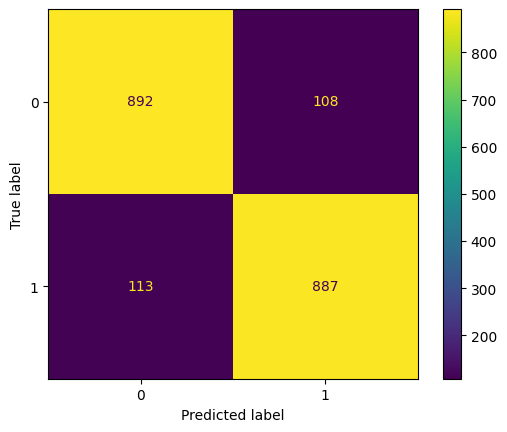

In [15]:
y_pred = cross_val_predict(best_model_lr, x, y, cv=skf)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

The new score of 0.89 we get is not better than what we had for tuned SVC.

### Model 3: Transformer

Followed this guide: https://huggingface.co/docs/transformers/tasks/sequence_classification

In [162]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, shuffle=True, random_state=0
)

In [163]:
from datasets import DatasetDict, Dataset

#### Dataset Preparation

In [164]:
movies = DatasetDict(
    {
        "train": Dataset.from_dict({"text": x_train, "label": y_train}),
        "test": Dataset.from_dict({"text": x_test, "label": y_test}),
    }
)
movies

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1600
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 400
    })
})

#### Preprocess

In [165]:
# model_name = "distilbert/distilbert-base-uncased"
model_name = "FacebookAI/roberta-large"

In [166]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [167]:
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True)

In [168]:
tokenized_movies = movies.map(preprocess_function, batched=True)

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

In [169]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

#### Evaluate

In [170]:
import evaluate

accuracy = evaluate.load("accuracy")

In [171]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

#### Train

In [172]:
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

In [175]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [178]:
training_args = TrainingArguments(
    output_dir="bert-model",
    learning_rate=2e-5,
    per_device_train_batch_size=5,
    per_device_eval_batch_size=5,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    # push_to_hub=True,
    dataloader_pin_memory=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_movies["train"],
    eval_dataset=tokenized_movies["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.403553,0.910000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

Right now we seem to have ~85% accuracy let's see if we can improve it

In [31]:
training_args.num_train_epochs = 6
trainer.train(resume_from_checkpoint=True)

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Epoch,Training Loss,Validation Loss,Accuracy
4,No log,0.355250,0.857500
5,0.155379,0.420786,0.855000
6,0.155379,0.423092,0.870000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=600, training_loss=0.06253781716028849, metrics={'train_runtime': 244.8171, 'train_samples_per_second': 39.213, 'train_steps_per_second': 2.451, 'total_flos': 1271687027097600.0, 'train_loss': 0.06253781716028849, 'epoch': 6.0})

Maybe we are overfitting but the accuracy is incereasing so let's keep going.

In [32]:
training_args.num_train_epochs = 9
trainer.train(resume_from_checkpoint=True)

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Epoch,Training Loss,Validation Loss,Accuracy
7,0.155379,0.491200,0.860000
8,0.155379,0.527762,0.865000
9,0.155379,0.527215,0.862500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=900, training_loss=0.014334950976901585, metrics={'train_runtime': 263.3362, 'train_samples_per_second': 54.683, 'train_steps_per_second': 3.418, 'total_flos': 1907530540646400.0, 'train_loss': 0.014334950976901585, 'epoch': 9.0})

The accuracy seems to have peaked at around ~87% which is disappointing as it is worse than our TF-IDF models

### Model 4: LLM

In [96]:
from sklearn.metrics import classification_report

In [124]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, shuffle=True, random_state=0
)

model_lr = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                max_df=0.9,
                min_df=4,
                ngram_range=(1, 2),
                sublinear_tf=True,
            ),
        ),
        ("clf", LogisticRegression(C=10)),
    ]
)  # Did a bit of empirical testing for the parameters

model_lr.fit(x_train, y_train)
y_pred = model_lr.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       250
           1       0.88      0.90      0.89       250

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



In [131]:
x_test[3]

"kevin smith is like a big kid . his humor is that of a sophisticated juvenile's . he grew up idolizing star wars and loves comic books , having also written a few . he also has a cult following , mostly composed of teenagers , college students , and smith's own fellow adolescent-minded grownups . smith is hilarious in person and in writing , but when he tries to be earnest and moralize , that is when he goes wrong . kevin smith is a better writer than director , and he'll be the first to tell you that . that might also be part of the reason why his moralizing comes across as so heavy-handed . great directors show us their theses instead of having the characters sermonize them . this was true in the overrated chasing amy , and it is true for dogma as well . that is not to say smith's message is a bad one . in dogma , smith tells us that problems arise when people believe beyond any doubt that their insight into god and god's desires is superior to anyone else's . basically , dogmatism 

In [130]:
y_pred == y_test

array([ True,  True,  True, False,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True, False, False,
        True, False,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True, False,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True, False,  True,  True, False,  True,  True,  True,
        True, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,

In [126]:
model_lr.predict_proba(x_test)

array([[0.59702272, 0.40297728],
       [0.78694806, 0.21305194],
       [0.2204077 , 0.7795923 ],
       [0.57565691, 0.42434309],
       [0.69276237, 0.30723763],
       [0.22796102, 0.77203898],
       [0.54930509, 0.45069491],
       [0.63839571, 0.36160429],
       [0.79032728, 0.20967272],
       [0.63825643, 0.36174357],
       [0.41642518, 0.58357482],
       [0.24429828, 0.75570172],
       [0.13004371, 0.86995629],
       [0.32753305, 0.67246695],
       [0.2887794 , 0.7112206 ],
       [0.57540756, 0.42459244],
       [0.87739203, 0.12260797],
       [0.19031456, 0.80968544],
       [0.31445082, 0.68554918],
       [0.04139087, 0.95860913],
       [0.30985699, 0.69014301],
       [0.33940905, 0.66059095],
       [0.54486146, 0.45513854],
       [0.79000986, 0.20999014],
       [0.43445803, 0.56554197],
       [0.79474234, 0.20525766],
       [0.30361131, 0.69638869],
       [0.85767368, 0.14232632],
       [0.16172754, 0.83827246],
       [0.85418608, 0.14581392],
       [0.

In [135]:
y_test[3]

1

In [157]:
x_eval_sub = x_eval[12400:12600]
y_eval_sub = y_eval[12400:12600]

In [ ]:
from ollama import chat
from tqdm.notebook import tqdm

# llm_model = "qwen3.5:0.8b"
llm_model = "qwen3.5:latest"


def predict_llm(reviews: list[str], llm_model: str = llm_model):
    responses = []
    for review in tqdm(reviews):
        response = chat(
            model=llm_model,
            messages=[
                {
                    "role": "user",
                    "content": f"Answer with a single word either 'positive' or 'negative'.\nIs this movie critic review positive or negative towards the film:\n{review}",
                }
            ],
            think=False,
            stream=False,
        )
        responses.append(response.message.content)
    return [1 if response == "positive" else 0 for response in responses]

In [159]:
y_eval_sub_pred = predict_llm(x_eval_sub)

  0%|          | 0/200 [00:00<?, ?it/s]

With the larger model qwen3.5:latest the score is about 89% but for the smaller model the score is about 80%

In [161]:
print(classification_report(y_eval_sub, y_eval_sub_pred))

              precision    recall  f1-score   support

           0       0.97      0.86      0.91       100
           1       0.87      0.97      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200



In [ ]:
print(classification_report(y_eval_sub, y_eval_sub_pred))

              precision    recall  f1-score   support

           0       0.77      0.84      0.80       100
           1       0.82      0.75      0.79       100

    accuracy                           0.80       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.80      0.79       200



In [134]:
preds

[0]

In [82]:
y_pred = [1 if pred == "positive" else 0 for pred in preds]

In [87]:
(np.array(y_pred[:100]) == np.array(y_train[:100])).sum() / 100

np.float64(0.96)

In [66]:
print(x_train[5])

tibet has entered the american consciousness slowly during the past few years and burst into the forefront recently . the dalai lama has made speaking tours , tibetan designs and artifacts are showing up in shops , the plight of the people has captured the imagination of major actors and artists and now there are two big budget films within as many months .  " kundun " ( " presence " , a name the monks call the young dalai lama ) opens in 1937 with the search for the 14th incarnation of the tibetan leader . a group of monks enters a village and a two-year-old child catches their attention . the young boy proves himself by identifying possessions of the previous holy man as " mine " . he and his family are then moved to a monastery in lhassa where he is to be prepared to take his position as the religious and political leader of the country . he is forced into difficult decisions when china invades the country in 1950 . the peaceful and isolated country is ill-equipped to fight off the 

In [64]:
y_train[:10]

[0, 0, 1, 1, 1, 1, 1, 0, 0, 0]

In [ ]:
# response = chat(
#     model=llm_model,
#     messages=[
#         {
#             "role": "user",
#             "content": f"Answer with a single word either 'positive' or 'negative'.\nIs this review positive or negative:\n{x[0]}",
#         },
#     ],
#     think=False,
#     stream=False,
# )

# print("Thinking:\n", response.message.thinking)
# print("Answer:\n", response.message.content)